In [1]:
from typing import TypedDict
from typing_extensions import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import HumanMessage
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

True

In [2]:
## create the state
class State(TypedDict):
    messages: Annotated[list, add_messages] ## you need add messages into the list type with the help of add_messages

In [3]:
## llm object
llm_gai = ChatGoogleGenerativeAI(
            model = "gemini-3.5-flash-lite",
            max_tokens = 346,
)

In [4]:
## Node Functionality for creating node
def ChatBot_node(state: State): ## Uses the State to add new messages to the conversation
    return {"messages": [llm_gai.invoke(state["messages"])]} ## this will append the every messages into the state variable

## **CHATBOT BUILDING**

In [5]:
## we can use State class to create graph state
## graph builder object to build chatbot or agent in a graph
graph_builder = StateGraph(State)

## define nodes
graph_builder.add_node("SarojChatBot", ChatBot_node)

## define edges
graph_builder.add_edge(START, "SarojChatBot")
graph_builder.add_edge("SarojChatBot", END)

## compile all
graph = graph_builder.compile()


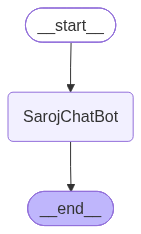

In [6]:
## for visualization
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [7]:
# ## To run the entire pipeline
# result = graph.invoke({
#     "messages": [HumanMessage(content="Hi")] 
# })

# print(result['messages'][-1].content)

In [8]:
## To run the entire pipeline
result = graph.invoke({
    "messages": ["Hi"] 
})

# print(result['messages'][-1].content)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [9]:
result['messages'][-1].text ## Annotated helps to label my input messages into a human messages (HumanMessage)

'Hi there! How can I help you today?'

## **CHATBOT WITH TOOL**

In [10]:
## initialize
tool = TavilySearch(max_results=2)

tool.invoke("What is AI agent")

{'query': 'What is AI agent',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/ai-agents',
   'title': 'What are AI Agents?',
   'content': 'An artificial intelligence (AI) agent is a software program that can interact with its environment, collect data, and use that data to perform self-directed tasks that meet predetermined goals. Humans set goals, but an AI agent independently chooses the best actions it needs to perform to achieve those goals. For example, consider a contact center AI agent that wants to resolve customer queries. The agent will automatically ask the customer different questions, look up information in internal [...] For example, in autonomous vehicle fleets, each vehicle acts as an independent agent but collaborates with others to avoid traffic congestion and prevent collisions, leading to smoother traffic flow.\n\n## What are the challenges of using AI agents?\n\nAI agents are helpful software techn

In [11]:
## simple tool
def greeting_tool(greet: str):
    """
    Greet them saying - Namaste🙏, Mero naam AI ho!

    Args:
        greet (str): input says - Hello or Hi.

    Returen:
        str: Output with Nepali way of greetings.
    """


In [12]:
## list of tool
tools = [tool, greeting_tool]


## bind the llm with list of tools
llm_tools = llm_gai.bind_tools(tools)

In [13]:
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

## define tools
def tool_calling_llm(state: State):
    return {"messages": [llm_tools.invoke(state['messages'])]}

## Node graph 
builder = StateGraph(State)
builder.add_node("Saroj_tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## edge graph
builder.add_edge(START, "Saroj_tool_calling_llm")
builder.add_conditional_edges(
    "Saroj_tool_calling_llm",
    # if the latest message (result) from the assistance is a tool call -> tool_condition routes to tool
    # if the latest message (result) from the assistance is not a tool call -> tool_condition routes to END
    tools_condition
 )

builder.add_edge("Saroj_tool_calling_llm", END)

## compile the entire graph
Bot_graph = builder.compile()


In [17]:
response = Bot_graph.invoke({"messages": ["What is langchain?"]})

response['messages'][-1].text

'{"query": "what is langchain", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://aws.amazon.com/what-is/langchain", "title": "What is LangChain?", "content": "LangChain is an open source framework for building applications based on large language models (LLMs). LLMs are large deep-learning models pre-trained on large amounts of data that can generate responses to user queries—for example, answering questions or creating images from text-based prompts. LangChain provides tools and abstractions to improve the customization, accuracy, and relevancy of the information the models generate. For example, developers can use LangChain components to build new [...] LangChain provides AI developers with tools to connect language models with external data sources. It is open-source and supported by an active community. Organizations can use LangChain for free and receive support from other developers proficient in the framework.\\n\\n## How does LangChain wor

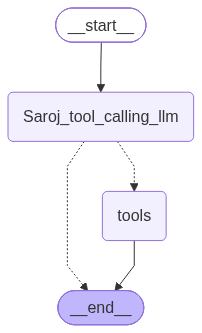

In [18]:
Bot_graph